# 50 Startups Profit Prediction

The data collected from New York, California and Florida about 50 business Startups. 

* The independent variables used in this dataset are R&D spending, Administration, Marketing Spending and State.

* The dependent variable is Profit.

## Import Libraries

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [ ]:
data = pd.read_csv('50_Startups.csv')
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Data Overview

In [77]:
data.shape

(50, 5)

In [78]:
data.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='str')

In [79]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.5 KB


In [80]:
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


### Rename Some Columns

In [81]:
data.rename({'Marketing Spend': "Marketing_Spend", 
           'R&D Spend':'R&D_Spend'}, axis=1, inplace=True)

### Checking Missing Data

In [82]:
data.isnull().sum()

R&D_Spend          0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

### Checking Duplicate Rows

In [83]:
data.duplicated().sum()

np.int64(0)

- The dataset contains 50 observations with no missing values or duplicate records.

## EDA

### Distribution of Numerical Features

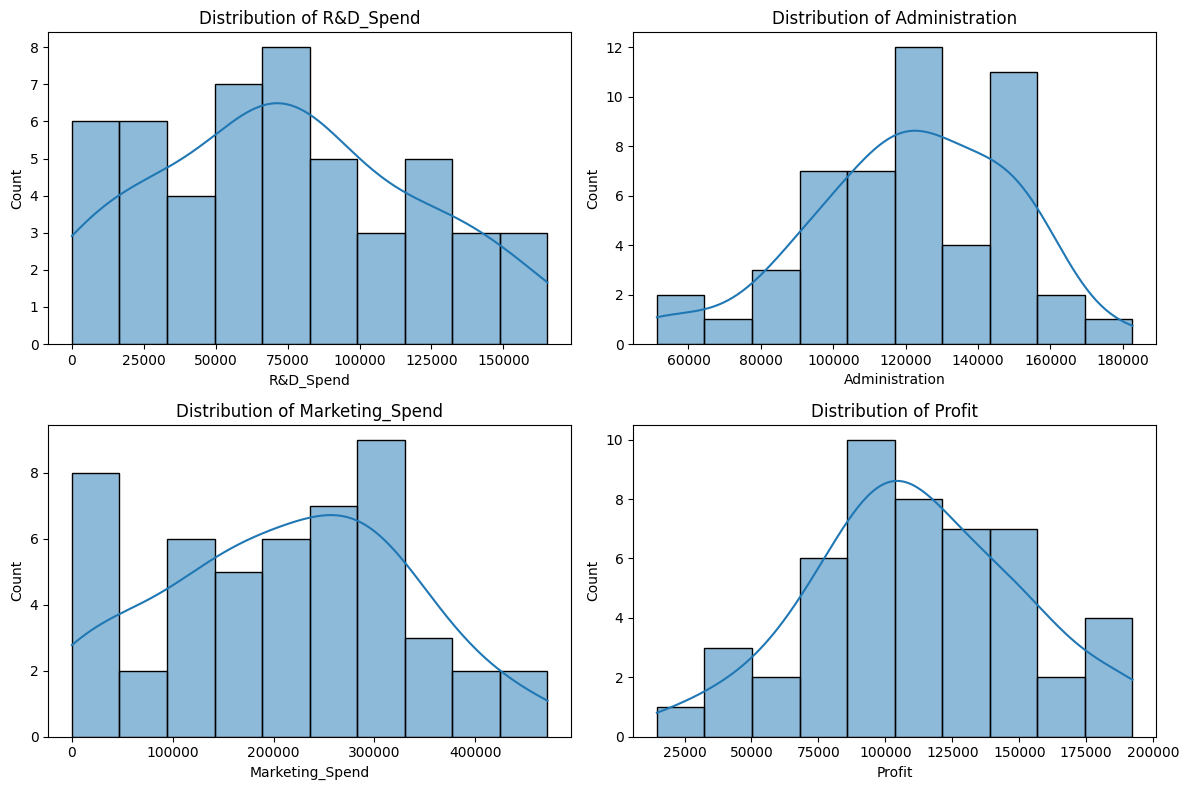

In [84]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(['R&D_Spend', 'Administration', 'Marketing_Spend', 'Profit'], 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=data, x=col, bins=10, kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### State Distribution

In [85]:
data["State"].unique()

<ArrowStringArray>
['New York', 'California', 'Florida']
Length: 3, dtype: str

In [86]:
data['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_4076\2495746995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="State", data=data, palette="Set1");


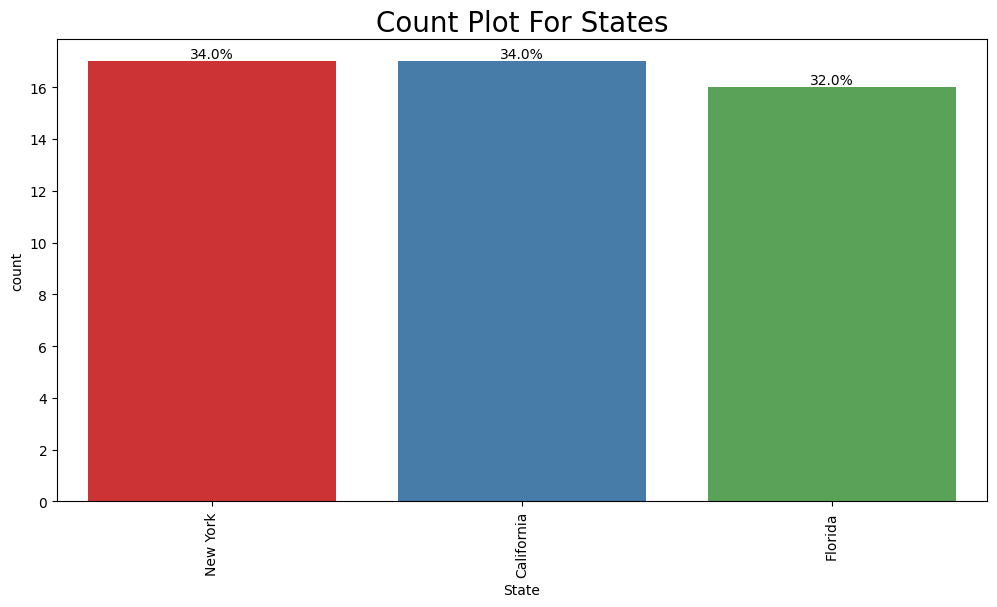

In [87]:
plt.figure(figsize=(12,6))
total = float(len(data))
ax = sns.countplot(x="State", data=data, palette="Set1");
plt.xticks(rotation=90)
plt.title("Count Plot For States", fontsize=20)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center',va='bottom')
plt.show()

- The three states are almost equally represented in the dataset.

### Relationships

C:\Users\hp\AppData\Local\Temp\ipykernel_4076\1356174615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.boxplot(x= 'State', y= 'Profit', data = data.sort_values('Profit',ascending=False), palette='Set2')


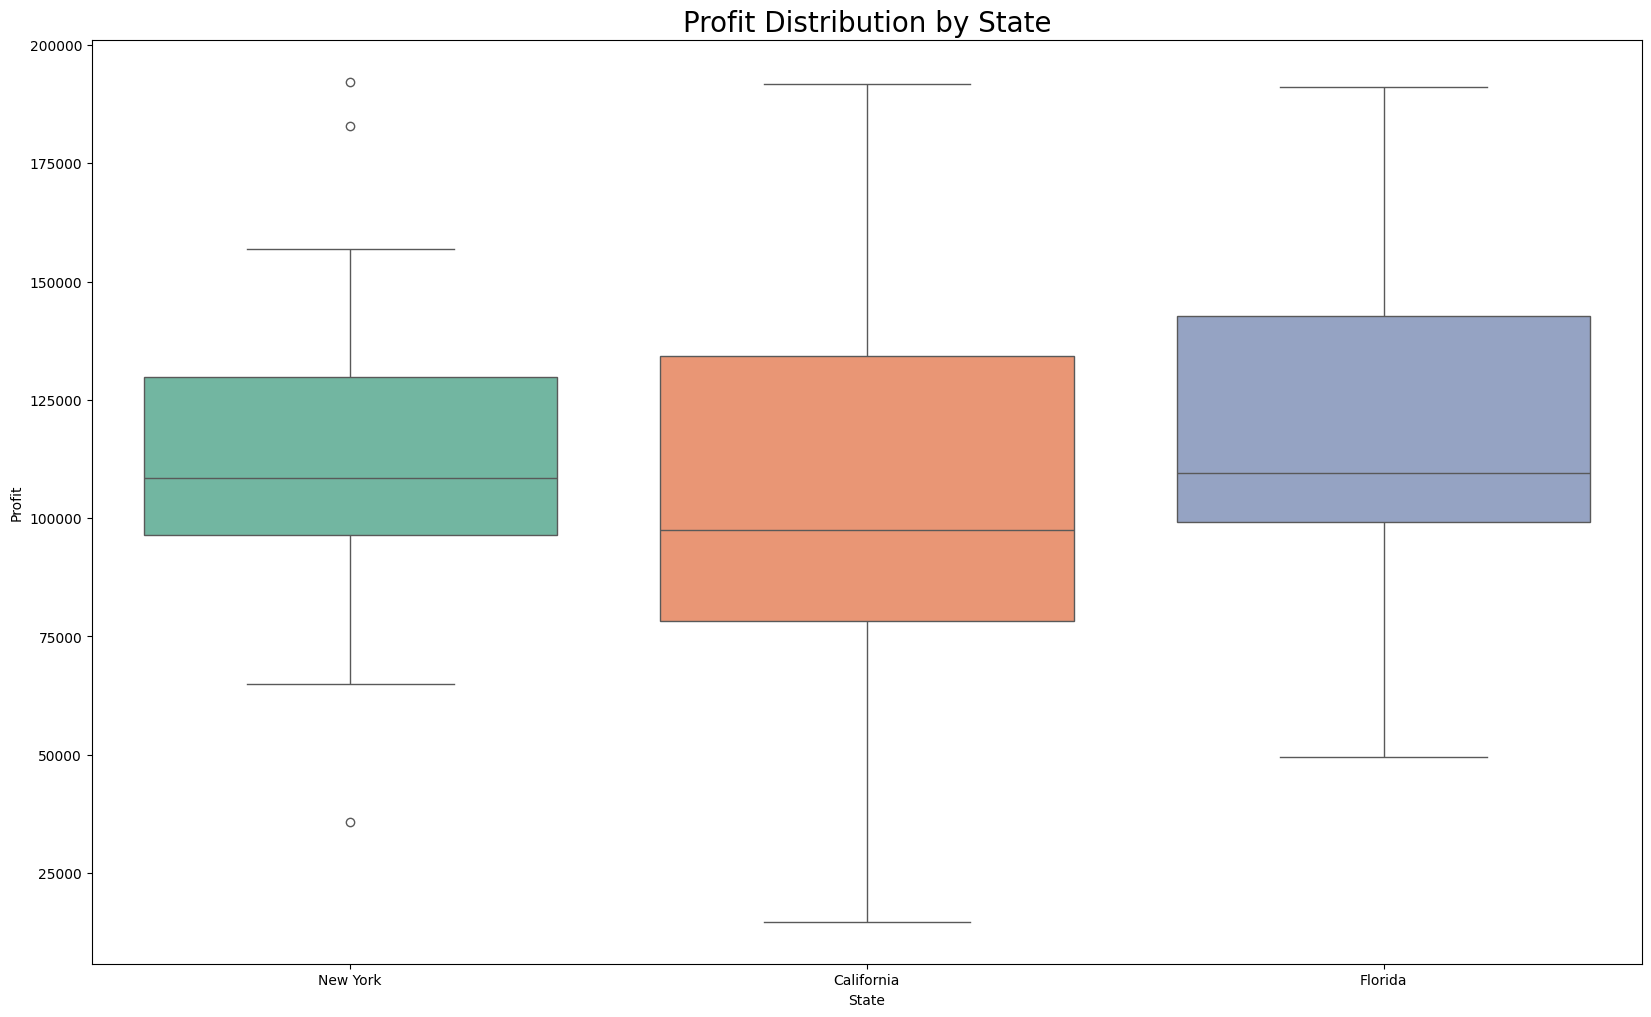

In [88]:
plt.figure(figsize=(20,12))
fig = sns.boxplot(x= 'State', y= 'Profit', data = data.sort_values('Profit',ascending=False), palette='Set2')

plt.title("Profit Distribution by State", fontsize=20)
plt.show()

In [89]:
data.loc[:, data.columns != "State"].corr()["Profit"].sort_values(ascending=False)

Profit             1.000000
R&D_Spend          0.972900
Marketing_Spend    0.747766
Administration     0.200717
Name: Profit, dtype: float64

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

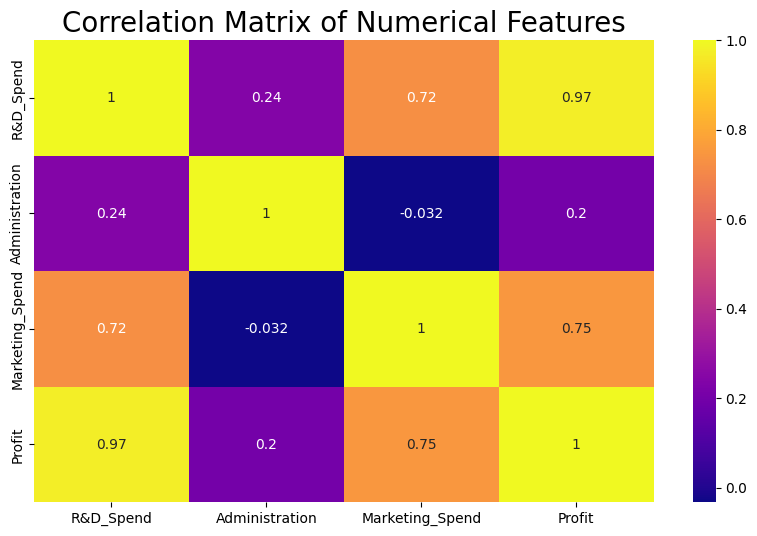

In [90]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='plasma')

plt.title("Correlation Matrix of Numerical Features", fontsize=20)


Text(0.5, 1.0, 'R&D Spend vs. Profit')

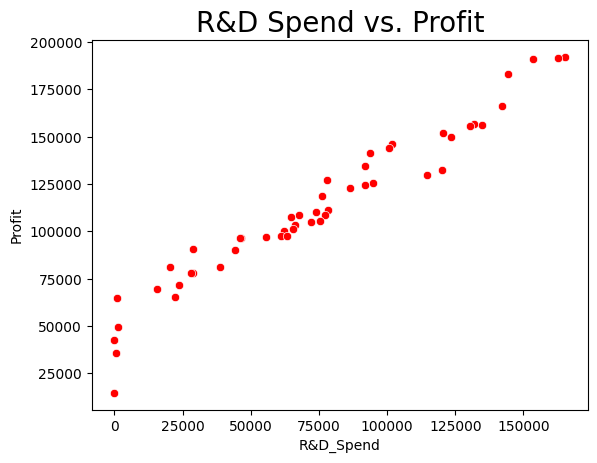

In [91]:
sns.scatterplot(x='R&D_Spend',y='Profit',data=data , color="red");

plt.title("R&D Spend vs. Profit", fontsize=20)

Text(0.5, 1.0, 'Marketing Spend  vs. Profit')

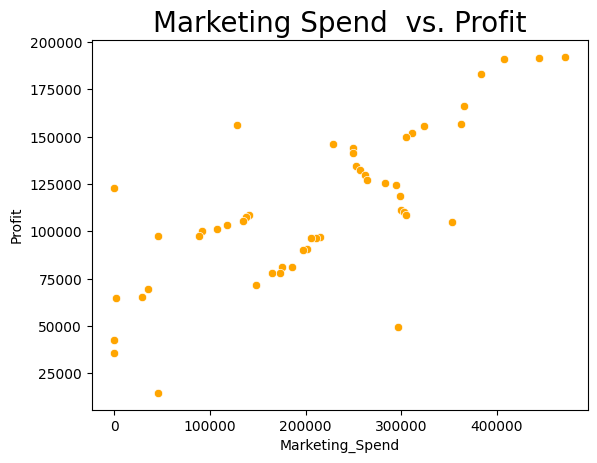

In [92]:
sns.scatterplot(x='Marketing_Spend',y='Profit',data=data , color="orange");

plt.title("Marketing Spend  vs. Profit", fontsize=20)

Text(0.5, 1.0, 'Administration Spend vs. Profit')

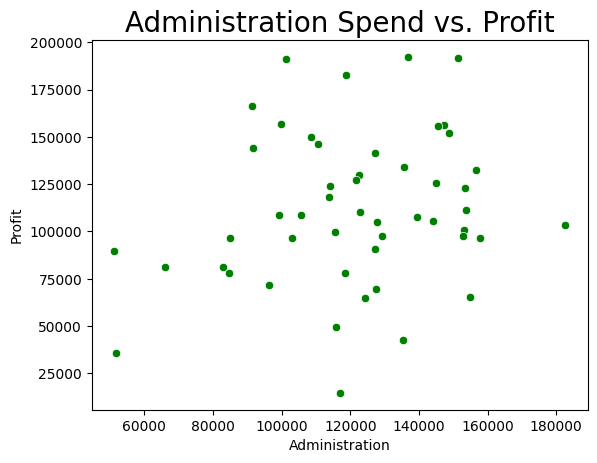

In [93]:
sns.scatterplot(x='Administration',y='Profit',data=data , color="green");

plt.title("Administration Spend vs. Profit", fontsize=20)

Text(0.5, 1.0, 'Relationship Between R&D Spend, Marketing Spend, and Profit')

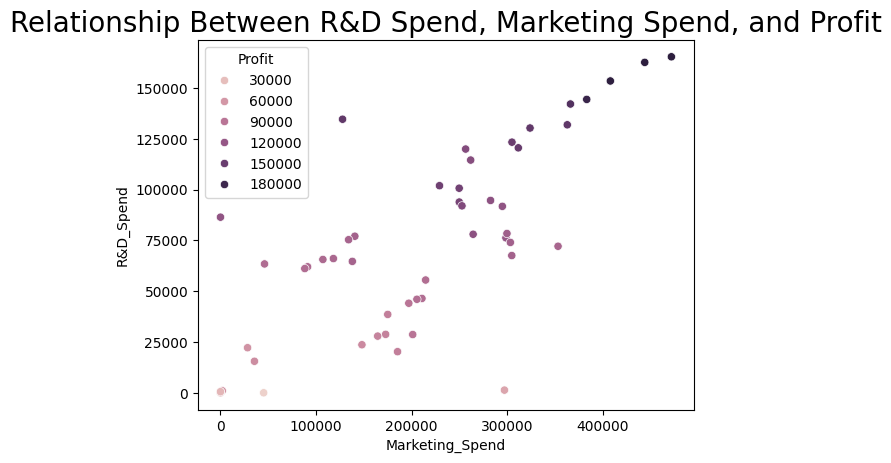

In [94]:
sns.scatterplot(x='Marketing_Spend', y='R&D_Spend', hue='Profit',data=data , color="orange");

plt.title("Relationship Between R&D Spend, Marketing Spend, and Profit", fontsize=20)


### Outlier Analysis

In [95]:
# IQR
numerical_cols = ['R&D_Spend', 'Administration', 'Marketing_Spend', 'Profit']

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

R&D_Spend: 0 outliers
Administration: 0 outliers
Marketing_Spend: 0 outliers
Profit: 1 outliers


In [96]:
Q1 = data['Profit'].quantile(0.25)
Q3 = data['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

profit_outlier = data[
    (data['Profit'] < lower_bound) |
    (data['Profit'] > upper_bound)
]

profit_outlier

,R&D_Spend,Administration,Marketing_Spend,State,Profit
49,0.0,116983.8,45173.06,California,14681.4


In [97]:
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 15698.290000000023
Upper Bound: 214206.58999999997


## Exploratory Data Analysis Insights

### 1. Data Quality
- The dataset contains 50 startups and 5 variables.
- No missing values or duplicate records were detected.
- The dataset consists of four numerical variables (`R&D Spend`, `Administration`, `Marketing Spend`, and `Profit`) and one categorical variable (`State`).

### 2. Numerical Feature Distributions
- The numerical variables are distributed across relatively wide ranges, with no obvious severe skewness.
- `R&D Spend` and `Marketing Spend` include zero values, indicating that some startups reported no expenditure in these categories.
- Profit varies considerably across startups, ranging from approximately 15K to 192K.
- A few extreme observations are visible and may require further investigation, but they should not be removed without evidence that they are erroneous or harmful to the model.

### 3. State Distribution
- The startups are almost evenly distributed across the three states:
  - New York: 34%
  - California: 34%
  - Florida: 32%
- Therefore, there is no major geographical imbalance in the dataset.

### 4. Correlation Analysis
- `R&D Spend` has a very strong positive correlation with `Profit` (r ≈ 0.97), making it the strongest potential predictor of profit.
- `Marketing Spend` has a strong positive correlation with `Profit` (r ≈ 0.75).
- `Administration` has only a weak positive correlation with `Profit` (r ≈ 0.20).
- `R&D Spend` and `Marketing Spend` are also positively correlated (r ≈ 0.72), suggesting some potential multicollinearity between these predictors.

### 5. Feature Relationships with Profit
- The scatter plot between `R&D Spend` and `Profit` shows a clear and approximately linear positive relationship: startups that spend more on R&D generally achieve higher profits.
- `Marketing Spend` also tends to increase with profit, although the relationship is more dispersed than that of R&D Spend.
- `Administration Spend` shows no clear linear pattern with profit, which is consistent with its relatively low correlation coefficient.
- The combined R&D and Marketing visualization further suggests that high R&D spending is more consistently associated with high-profit startups than high marketing spending alone.

### 6. State and Profit
- Median profit varies somewhat between New York, California, and Florida.
- However, the profit distributions across the three states overlap substantially.
- This suggests that `State` may have less predictive influence on profit compared with variables such as `R&D Spend`.
- Some potential outliers are visible, particularly among New York startups.

### 7. Outlier Analysis

- The IQR method detected no outliers in `R&D Spend`, `Administration`, or `Marketing Spend`. One potential outlier was identified in `Profit`.

- The identified observation has a profit of approximately $14,681, slightly below the calculated IQR lower bound of approximately $15,698.

- However, the observation does not appear to be erroneous. The startup reported zero R&D spending and relatively low marketing spending, making its low profit economically plausible and consistent with the patterns observed during EDA.

- Therefore, the observation was retained to avoid unnecessary information loss, particularly given the small dataset size of only 50 observations.

___
## Splitting Data

**split the data** 

X: Features

y: Target (`Profit`)

In [98]:
X = data.drop(['Profit'], axis=1)
y = data['Profit']

In [99]:
# Train, Test data split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state= 42)

In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 4)
(10, 4)
(40,)
(10,)


## Data Preprocessing

In [101]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = ['R&D_Spend', 'Administration', 'Marketing_Spend']
cat_cols = ['State']

scaler = MinMaxScaler()
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers= [('scaler', scaler, num_cols),
                   ('encoder', encoder, cat_cols)]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


## Modeling

### Linear Regression Model

Linear Regression was used as the first regression model to predict startup profit based on the transformed input features.

In [102]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()

linear_regression_model.fit(X_train, y_train)

print('Training score:', linear_regression_model.score(X_train, y_train))
print('Test score:', linear_regression_model.score(X_test, y_test))
print("__________________________________________________")
print("Intercept of the model:", linear_regression_model.intercept_.round(2))
print("Coefficient of the line:", linear_regression_model.coef_.round(2))

Training score: 0.9537019995248525
Test score: 0.8987266414319839
__________________________________________________
Intercept of the model: 50500.38
Coefficient of the line: [ 1.3321029e+05 -9.0361400e+03  1.4085320e+04  9.3879000e+02
  6.9900000e+00]


In [ ]:
# Model Coefficients
coef_df = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Coefficient': linear_regression_model.coef_
})

coef_df

,Feature,Coefficient
0,scaler__R&D_Spend,133210.286532
1,scaler__Administration,-9036.142683
2,scaler__Marketing_Spend,14085.323269
3,encoder__State_Florida,938.793006
4,encoder__State_New York,6.987760


### Decision Tree Model

In [104]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_model = DecisionTreeRegressor(max_depth=5, random_state=0)

decision_tree_model.fit(X_train, y_train)
print('Training score:',decision_tree_model.score(X_train, y_train))
print('Test score:',decision_tree_model.score(X_test, y_test))

Training score: 0.9992097709051426
Test score: 0.8014814646479143


In [105]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['scaler__R&D_Spend', 'scaler__Administration',
       'scaler__Marketing_Spend', 'encoder__State_Florida',
       'encoder__State_New York'], dtype=object)

#### Decision Tree Visualization

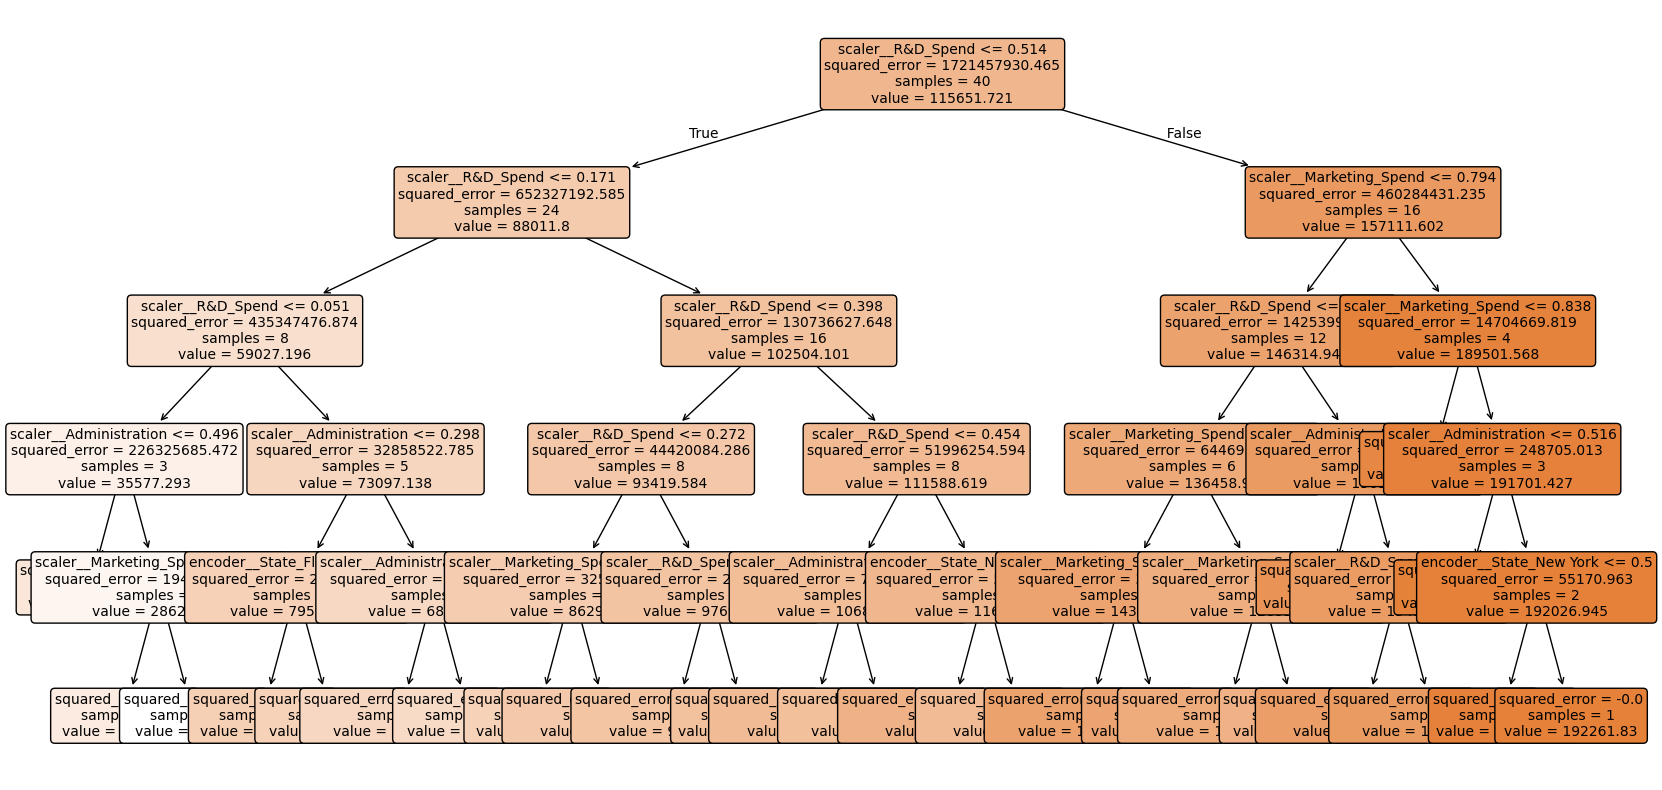

In [106]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(decision_tree_model, feature_names=feature_names, filled=True, rounded=True, fontsize=10);

plt.show()

## Model Evaluation

In [107]:
linear_pred = linear_regression_model.predict(X_test)
dt_pred = decision_tree_model.predict(X_test)

comparison_df = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Linear Regression': linear_pred,
    'Decision Tree': dt_pred
})

comparison_df

,Actual Profit,Linear Regression,Decision Tree
0,134307.35,126362.879083,141585.5200
1,81005.76,84608.453836,78239.9100
2,99937.59,99677.494252,96863.6975
3,64926.08,46357.460686,42559.7300
4,125370.37,128750.482885,124266.9000
5,35673.41,50912.417419,49490.7500
6,105733.54,109741.350327,122733.4800
7,107404.34,100643.242816,101004.6400
8,97427.84,97599.275746,101004.6400
9,122776.86,113097.425244,145190.6750


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }

In [110]:
linear_results = evaluate_model(
    'Linear Regression',
    y_test,
    linear_pred
)

dt_results = evaluate_model(
    'Decision Tree',
    y_test,
    dt_pred
)

model_results = pd.DataFrame([
    linear_results,
    dt_results
])

model_results

,Model,MAE,RMSE,R²
0,Linear Regression,6961.477813,9055.957323,0.898727
1,Decision Tree,9979.532750,12679.066859,0.801481


### Model Comparison

- Linear Regression outperformed the Decision Tree Regressor on the test set.

- It achieved a lower MAE and RMSE, indicating smaller prediction errors, and a higher R² score of 0.899 compared with 0.801 for the Decision Tree.

- Therefore, Linear Regression was selected as the better-performing model for this dataset.

In [118]:
final_results = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': linear_pred
})

final_results

,Actual Profit,Predicted Profit
0,134307.35,126362.879083
1,81005.76,84608.453836
2,99937.59,99677.494252
3,64926.08,46357.460686
4,125370.37,128750.482885
5,35673.41,50912.417419
6,105733.54,109741.350327
7,107404.34,100643.242816
8,97427.84,97599.275746
9,122776.86,113097.425244


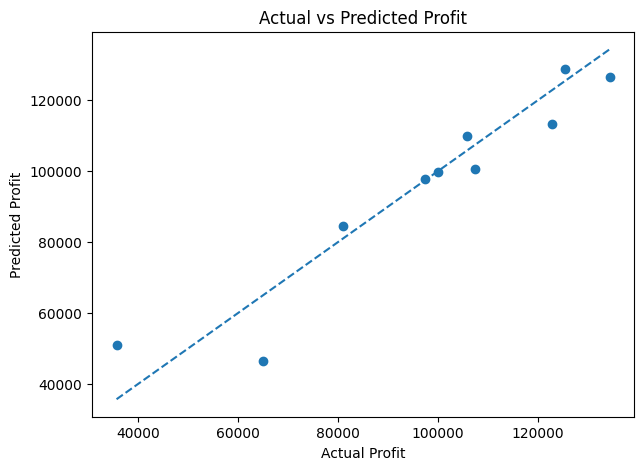

In [120]:
plt.figure(figsize=(7, 5))

plt.scatter(
    final_results['Actual Profit'],
    final_results['Predicted Profit']
)

min_value = min(
    final_results['Actual Profit'].min(),
    final_results['Predicted Profit'].min()
)

max_value = max(
    final_results['Actual Profit'].max(),
    final_results['Predicted Profit'].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    '--'
)

plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')

plt.show()

### Actual vs Predicted Analysis

Most predicted profit values are relatively close to the actual values, as the majority of points lie near the ideal prediction line.

However, some larger prediction errors can be observed, particularly for a few startups with lower profit values.

Overall, the plot indicates that the Linear Regression model provides a good fit to the test data.

In [121]:
residuals = y_test.values - linear_pred

residual_results = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': linear_pred,
    'Residual': residuals
})

residual_results

,Actual Profit,Predicted Profit,Residual
0,134307.35,126362.879083,7944.470917
1,81005.76,84608.453836,-3602.693836
2,99937.59,99677.494252,260.095748
3,64926.08,46357.460686,18568.619314
4,125370.37,128750.482885,-3380.112885
5,35673.41,50912.417419,-15239.007419
6,105733.54,109741.350327,-4007.810327
7,107404.34,100643.242816,6761.097184
8,97427.84,97599.275746,-171.435746
9,122776.86,113097.425244,9679.434756


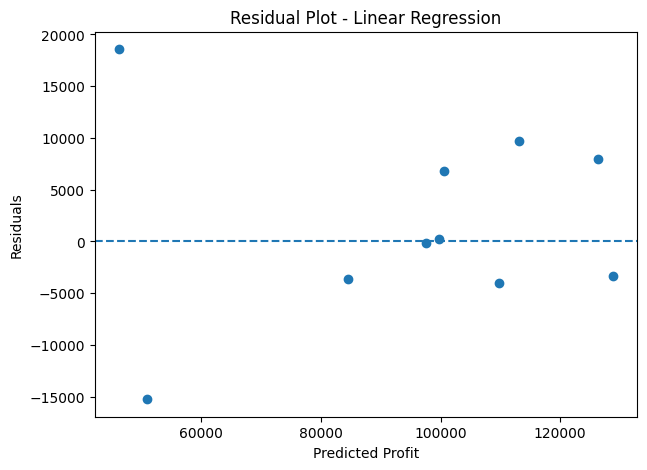

In [122]:
plt.figure(figsize=(7, 5))

plt.scatter(linear_pred, residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Profit')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')

plt.show()

### Residual Analysis

The residuals are distributed on both sides of the zero line without a clear systematic pattern, suggesting that the Linear Regression model does not show an obvious prediction bias on the test data.

However, a few relatively large residuals are present, particularly for some lower predicted profit values.

Since the test set contains only 10 observations, the residual plot should be interpreted with caution.

## Key Findings

- R&D Spend showed the strongest positive relationship with Profit.
- Marketing Spend also showed a positive relationship with Profit, while Administration Spend had a relatively weak relationship.
- Linear Regression outperformed the Decision Tree Regressor on the test set.
- Linear Regression achieved an R² score of 0.899, compared with 0.801 for the Decision Tree.
- Linear Regression also achieved lower MAE and RMSE values, indicating smaller prediction errors.
- The Actual vs Predicted plot showed that most predictions were relatively close to the actual profit values.
- The residual analysis did not reveal a clear systematic error pattern, although some relatively large residuals were observed.

## Limitations

- The dataset contains only 50 startups, which limits the amount of data available for training and testing.
- The test set contains only 10 observations, so the evaluation results may be sensitive to the train-test split.
- Only a limited number of features are available to explain startup profitability.
- Therefore, the model's performance should not be assumed to generalize to all real-world startups.

## Conclusion

This project aimed to predict startup profit using R&D Spend, Administration Spend, Marketing Spend, and State.

Exploratory data analysis showed that R&D Spend had the strongest relationship with Profit, while Marketing Spend also showed a positive relationship and Administration Spend had a relatively weak relationship.

Two regression models were evaluated: Linear Regression and Decision Tree Regressor. Linear Regression achieved the better overall performance, with an R² score of 0.899, MAE of 6,961.48, and RMSE of 9,055.96. In comparison, the Decision Tree achieved an R² score of 0.801 with higher prediction errors.

Based on these results, Linear Regression was selected as the better-performing model for this dataset. Overall, the project demonstrates how exploratory data analysis, preprocessing, regression modeling, and model evaluation can be combined to predict startup profitability.